In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Preflight checks for notebook runtime
import importlib
from pathlib import Path
import sys

print("Preflight: checking environment and required files...")

# Required top-level packages
reqs = ["numpy", "pandas", "matplotlib", "sklearn", "tqdm"]
missing_pkgs = []
for pkg in reqs:
    try:
        importlib.import_module(pkg)
    except Exception:
        missing_pkgs.append(pkg)

if missing_pkgs:
    print("Missing Python packages:", missing_pkgs)
    print("Install with: pip install " + " ".join(missing_pkgs))
else:
    print("All required packages appear installed.")

# Look for dataset in common locations
candidates = [
    Path.cwd() / "clean_dataset.csv",
    Path.cwd().parent / "clean_dataset.csv",
    Path.cwd().parent.parent / "clean_dataset.csv",
    Path("clean_dataset.csv").resolve(),
    Path("../clean_dataset.csv").resolve(),
]
found = None
for p in candidates:
    if p.exists():
        found = p.resolve()
        break

if found:
    print(f"Found clean_dataset.csv at: {found}")
else:
    print("clean_dataset.csv not found in common locations. Please place dataset or update paths before running Section 2.")

# Check for key runtime variables (set by Sections 4-9)
needed_vars = ["v2_train", "v2_eval", "bundle_v2", "models_v2", "X_v2", "y_v2"]
missing_vars = [v for v in needed_vars if v not in globals()]
if missing_vars:
    print("Missing runtime variables:", missing_vars)
    print("Action: run Sections 1–9 (imports, data prep, training) before Section 12A.")
else:
    print("All key runtime variables present.")

print("Note: On Colab, mount Drive and re-run Sections 1–9 after any runtime reset.")


Preflight: checking environment and required files...
All required packages appear installed.
clean_dataset.csv not found in common locations. Please place dataset or update paths before running Section 2.
Missing runtime variables: ['v2_train', 'v2_eval', 'bundle_v2', 'models_v2', 'X_v2', 'y_v2']
Action: run Sections 1–9 (imports, data prep, training) before Section 12A.
Note: On Colab, mount Drive and re-run Sections 1–9 after any runtime reset.


# Optimal Ensemble Tuning and Validation

This notebook runs ablation studies, generalization validation, failure analysis, and overhead benchmarking for the Green-First Ensemble Meta-Scheduler. It mirrors the research-grade validation pipeline while keeping parameters editable for optimal ensemble usage.

## 1. Import Dependencies and Set Globals

Import libraries, set seeds, define constants, and configure plotting defaults.

In [3]:
from __future__ import annotations
import copy
import random
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

STEP_MINUTES = 5
STEP_HOURS = STEP_MINUTES / 60.0
HORIZON_STEPS = 288

OVERALL_WEIGHTS = {
    "carbon": 0.35,
    "jct": 0.20,
    "tail": 0.25,
    "preempt": 0.10,
    "starvation": 0.10,
}

CANDIDATE_ACTIONS = [1, 2, 3, 4]
ACTION_NAME = {1: "carbon", 2: "srtf", 3: "aged_srtf", 4: "carbon_guarded_short"}
GREEN_ACTION_BONUS = {1: 0.020, 2: 0.000, 3: 0.006, 4: 0.014}

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 110

print("Setup ready")

Setup ready


## 2. Resolve and Load Clean Dataset

Resolve the CSV path, validate required columns, and compute the power proxy feature.

In [4]:
def resolve_clean_dataset() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / "clean_dataset.csv",
        cwd.parent / "clean_dataset.csv",
        cwd.parent.parent / "clean_dataset.csv",
        Path("clean_dataset.csv").resolve(),
        Path("../clean_dataset.csv").resolve(),
        Path("../../clean_dataset.csv").resolve(),
        Path("/content/drive/MyDrive/EDI_Sem4/clean_dataset.csv"), # User's Colab folder
        Path("/content/drive/MyDrive/clean_dataset.csv"), # Common Colab
        Path("/content/drive/MyDrive/Eco-Cloud/clean_dataset.csv") # Alternative Colab
    ]
    for p in candidates:
        if p.exists():
            return p
    search_roots = [cwd, cwd.parent, cwd.parent.parent]
    for root in search_roots:
        if root.exists():
            try:
                hit = next(root.rglob("clean_dataset.csv"), None)
            except (OSError, PermissionError):
                # Skip roots that raise during traversal (e.g., /proc mounts on some systems)
                continue
            if hit is not None:
                return hit.resolve()
    raise FileNotFoundError("Could not find clean_dataset.csv. If using Colab, ensure it is in your Drive.")


def load_and_prepare_v1() -> pd.DataFrame:
    path = resolve_clean_dataset()
    df = pd.read_csv(path)
    required = {"job_name", "task_name", "start_time", "duration", "energy", "plan_cpu"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")
    df = df.dropna(subset=["start_time", "duration", "energy", "plan_cpu"]).copy()
    df["duration"] = df["duration"].clip(lower=1)
    df["energy"] = df["energy"].clip(lower=1e-6)
    df["plan_cpu"] = df["plan_cpu"].clip(lower=1.0)
    df["power_proxy"] = df["energy"] / df["duration"]
    return df


v1_df = load_and_prepare_v1()
print(f"Loaded clean dataset with {len(v1_df):,} rows")

Loaded clean dataset with 46,533 rows


## 3. Synthesize Real-World-Like Dataset

Create a stress-tested dataset with bursty arrivals, duration reshaping, and energy noise.

In [5]:
def create_realworld_like_dataset(df: pd.DataFrame, seed: int = 31415) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    out = df.copy().reset_index(drop=True)
    n = len(out)
    out["duration"] = out["duration"].astype(float)
    long_mask = rng.random(n) < 0.24
    short_mask = (~long_mask) & (rng.random(n) < 0.18)
    out.loc[long_mask, "duration"] = np.clip(
        out.loc[long_mask, "duration"] * rng.lognormal(mean=0.45, sigma=0.55, size=long_mask.sum()),
        1, np.quantile(out["duration"], 0.995) * 6.0,
    )
    out.loc[short_mask, "duration"] = np.clip(
        out.loc[short_mask, "duration"] * rng.uniform(0.35, 0.78, size=short_mask.sum()),
        1, None,
    )
    smin = float(out["start_time"].min())
    smax = float(out["start_time"].max())
    span = max(1.0, smax - smin)
    burst_centers = np.array([smin + 0.20 * span, smin + 0.52 * span, smin + 0.80 * span])
    burst_mask = rng.random(n) < 0.32
    selected_centers = rng.choice(burst_centers, size=burst_mask.sum(), p=[0.30, 0.45, 0.25])
    jitter = rng.normal(0.0, 0.03 * span, size=burst_mask.sum())
    out.loc[burst_mask, "start_time"] = np.clip(selected_centers + jitter, smin, smax).astype(int)
    cpu_norm = (out["plan_cpu"] / out["plan_cpu"].max()).clip(lower=0.05).to_numpy()
    dur = out["duration"].astype(float).to_numpy()
    baseline = out["energy"].astype(float).to_numpy()
    nonlinear = (0.012 * (dur ** 1.16)) * (1.0 + 0.35 * cpu_norm)
    burst_factor = np.ones(n, dtype=float)
    burst_factor[burst_mask] = rng.uniform(1.03, 1.20, size=burst_mask.sum())
    noise_factor = rng.normal(1.0, 0.07, size=n)
    out["energy"] = np.clip((0.35 * baseline + 0.65 * nonlinear) * burst_factor * noise_factor, 1e-6, None)
    miss_mask = rng.random(n) < 0.02
    out.loc[miss_mask, "energy"] = np.nan
    out["energy"] = out["energy"].interpolate(limit_direction="both")
    retry_mask = rng.random(n) < 0.06
    retries = out.loc[retry_mask].copy()
    if len(retries) > 0:
        retries["task_name"] = retries["task_name"].astype(str) + "_retry"
        retries["start_time"] = retries["start_time"].astype(float) + rng.integers(8, 160, size=len(retries))
        retries["duration"] = np.clip(retries["duration"] * rng.uniform(1.15, 1.85, size=len(retries)), 1, None)
        retries["energy"] = np.clip(retries["energy"] * rng.uniform(1.10, 1.40, size=len(retries)), 1e-6, None)
        out = pd.concat([out, retries], ignore_index=True)
    out["duration"] = out["duration"].round().clip(lower=1).astype(int)
    out["plan_cpu"] = out["plan_cpu"].round(2)
    out["energy"] = out["energy"].clip(lower=1e-6)
    out["power_proxy"] = out["energy"] / out["duration"].clip(lower=1)
    return out.sort_values("start_time").reset_index(drop=True)

print("Synthesizer ready")

Synthesizer ready


## 4. Train/Eval Split and Persistence

Split the synthesized dataset, save to disk, and reload if already present.

In [6]:
save_dir = Path("../data")
save_dir.mkdir(parents=True, exist_ok=True)
v2_path = save_dir / "clean_dataset_realworld_v2.csv"
if v2_path.exists():
    v2_df = pd.read_csv(v2_path)
    if "power_proxy" not in v2_df.columns:
        v2_df["power_proxy"] = v2_df["energy"] / v2_df["duration"].clip(lower=1)
else:
    v2_df = create_realworld_like_dataset(v1_df)
    v2_df.to_csv(v2_path, index=False)

v2_df = v2_df.reset_index(drop=True)
perm = np.random.default_rng(SEED).permutation(len(v2_df))
split_idx = int(0.80 * len(v2_df))
v2_train = v2_df.iloc[perm[:split_idx]].reset_index(drop=True)
v2_eval = v2_df.iloc[perm[split_idx:]].reset_index(drop=True)
if len(v2_eval) == 0:
    raise RuntimeError("v2_eval split is empty; adjust split ratio")

print(
    f"✓ Datasets loaded: v1 rows={len(v1_df):,} | v2 rows={len(v2_df):,} | "
    f"train rows={len(v2_train):,} | eval rows={len(v2_eval):,}"
)

✓ Datasets loaded: v1 rows=46,533 | v2 rows=49,290 | train rows=39,432 | eval rows=9,858


## 5. Define Simulation Environment

Define jobs, workload generation, carbon curve synthesis, shock injection, and the cluster environment.

In [7]:
@dataclass
class Job:
    job_id: int
    submit_step: int
    duration_steps: int
    power_kw: float

def make_workload_from_dataset(congestion: str, horizon_steps: int, rng: np.random.Generator, df: pd.DataFrame) -> list[Job]:
    jobs_per_regime = {"light": 90, "moderate": 160, "high": 250}
    n = jobs_per_regime[congestion]
    sampled = df.sample(n=n, replace=True, random_state=int(rng.integers(1, 1_000_000))).copy()
    smin, smax = float(df["start_time"].min()), float(df["start_time"].max())
    denom = max(1.0, smax - smin)
    sampled["submit_step"] = ((sampled["start_time"] - smin) / denom * (horizon_steps - 1)).round().astype(int)
    sampled["duration_steps"] = np.clip((sampled["duration"] / STEP_MINUTES).round().astype(int), 3, 120)
    q1 = sampled["power_proxy"].quantile(0.33)
    q2 = sampled["power_proxy"].quantile(0.66)
    def to_band(v: float) -> float:
        if v <= q1:
            return 1.2
        if v <= q2:
            return 2.0
        return 3.2
    sampled["power_kw"] = sampled["power_proxy"].apply(to_band)
    return [Job(i, int(r.submit_step), int(r.duration_steps), float(r.power_kw)) for i, r in enumerate(sampled.itertuples(index=False))]

def make_carbon_curve_stress(horizon_steps: int, rng: np.random.Generator, noise_pct: float = 10.0) -> np.ndarray:
    t = np.arange(horizon_steps)
    base = 260 + 120 * np.sin((2 * np.pi * t / horizon_steps) - (np.pi / 2))
    noise = rng.normal(0.0, (noise_pct / 100.0) * base)
    curve = np.clip(base + noise, 80, 650).copy()
    n_spikes = max(1, int(0.03 * horizon_steps))
    n_dips = max(1, int(0.02 * horizon_steps))
    spike_idx = rng.choice(np.arange(horizon_steps), size=n_spikes, replace=False)
    dip_idx = rng.choice(np.arange(horizon_steps), size=n_dips, replace=False)
    curve[spike_idx] += rng.uniform(80, 180, size=len(spike_idx))
    curve[dip_idx] -= rng.uniform(40, 100, size=len(dip_idx))
    return np.clip(curve, 80, 650)

def apply_workload_shocks(jobs: list[Job], rng: np.random.Generator, horizon_steps: int) -> list[Job]:
    shocked = []
    if not jobs:
        return jobs
    burst_center = int(rng.integers(int(0.25 * horizon_steps), int(0.75 * horizon_steps)))
    burst_half_window = 12
    for j in jobs:
        submit_step, duration_steps, power_kw = j.submit_step, j.duration_steps, j.power_kw
        if rng.random() < 0.30:
            submit_step = int(np.clip(rng.integers(burst_center - burst_half_window, burst_center + burst_half_window + 1), 0, horizon_steps - 1))
        if rng.random() < 0.12:
            duration_steps = int(np.clip(duration_steps * rng.uniform(1.4, 2.8), 3, 140))
        if rng.random() < 0.20:
            power_kw = float(np.clip(power_kw * rng.uniform(0.9, 1.25), 1.0, 4.0))
        shocked.append(Job(j.job_id, submit_step, duration_steps, power_kw))
    return shocked

class SimpleClusterEnv:
    def __init__(self, jobs: list[Job], carbon_curve: np.ndarray, capacity: int = 8, reward_weights: Optional[Dict[str, float]] = None):
        self.jobs = {j.job_id: j for j in jobs}
        self.job_order = sorted(jobs, key=lambda x: x.submit_step)
        self.curve = carbon_curve
        self.capacity = capacity
        self.max_step = len(carbon_curve)
        self.median_ci = float(np.median(carbon_curve))
        self.weights = reward_weights or OVERALL_WEIGHTS
        self.reset()

    def reset(self):
        self.step_idx = 0
        self.arrival_ptr = 0
        self.waiting = set()
        self.running = set()
        self.remaining = {jid: self.jobs[jid].duration_steps for jid in self.jobs}
        self.submit = {jid: self.jobs[jid].submit_step for jid in self.jobs}
        self.finish = {}
        self.prev_running = set()
        self.total_carbon_kg = 0.0
        self.total_preemptions = 0
        self.total_wait_steps = 0
        self.total_starvation_penalty = 0.0
        self.done = False
        return self._state()

    def _add_arrivals(self):
        while self.arrival_ptr < len(self.job_order) and self.job_order[self.arrival_ptr].submit_step <= self.step_idx:
            jid = self.job_order[self.arrival_ptr].job_id
            if jid not in self.finish:
                self.waiting.add(jid)
            self.arrival_ptr += 1

    def _active_jobs(self):
        return [jid for jid in self.jobs if jid not in self.finish and self.submit[jid] <= self.step_idx]

    def _state(self):
        ci = self.curve[min(self.step_idx, self.max_step - 1)]
        ci_norm = (ci - 80) / (650 - 80)
        queue_len = len(self.waiting)
        run_len = len(self.running)
        util = run_len / max(1, self.capacity)
        load = min(queue_len / (2 * max(1, self.capacity)), 1.0)
        if self.waiting:
            ages = [max(0, self.step_idx - self.submit[jid] + 1) for jid in self.waiting]
            p90_wait = float(np.percentile(ages, 90)) / 96.0
        else:
            p90_wait = 0.0
        active = self._active_jobs()
        long_ratio = float(np.mean([1.0 if self.remaining[j] >= 24 else 0.0 for j in active])) if active else 0.0
        return np.array([ci_norm, load, util, min(1.0, p90_wait), long_ratio], dtype=np.float32)

    def _policy_rank(self, policy_name: str):
        active = self._active_jobs()
        ci_now = self.curve[min(self.step_idx, self.max_step - 1)]
        if policy_name == "fcfs":
            ranked = sorted(active, key=lambda jid: (self.submit[jid], jid))
        elif policy_name == "carbon":
            if ci_now > self.median_ci:
                ranked = sorted(active, key=lambda jid: (self.jobs[jid].power_kw, self.submit[jid]))
            else:
                ranked = sorted(active, key=lambda jid: (-self.jobs[jid].power_kw, self.submit[jid]))
        elif policy_name == "srtf":
            ranked = sorted(active, key=lambda jid: (self.remaining[jid], self.submit[jid]))
        elif policy_name == "aged_srtf":
            ranked = sorted(active, key=lambda jid: (self.remaining[jid] - 0.15 * max(0, self.step_idx - self.submit[jid]), self.submit[jid]))
        elif policy_name == "carbon_guarded_short":
            if ci_now >= float(np.quantile(self.curve, 0.85)):
                ranked = sorted(active, key=lambda jid: (self.jobs[jid].power_kw, self.submit[jid]))
            else:
                ranked = sorted(active, key=lambda jid: (self.remaining[jid], self.submit[jid]))
        else:
            raise ValueError(f"Unknown policy: {policy_name}")
        return ranked[: self.capacity]

    def step(self, action_idx: int):
        self._add_arrivals()
        action_map = {0: "fcfs", 1: "carbon", 2: "srtf", 3: "aged_srtf", 4: "carbon_guarded_short"}
        selected = set(self._policy_rank(action_map[action_idx]))
        preemptions = len(self.prev_running - selected)
        self.total_preemptions += preemptions
        for jid in self._active_jobs():
            if jid in selected:
                self.running.add(jid)
                self.waiting.discard(jid)
            else:
                self.running.discard(jid)
                self.waiting.add(jid)
        ci = self.curve[min(self.step_idx, self.max_step - 1)]
        step_carbon_kg = 0.0
        finished_now = []
        for jid in list(self.running):
            self.remaining[jid] -= 1
            step_carbon_kg += (self.jobs[jid].power_kw * ci * STEP_HOURS) / 1000.0
            if self.remaining[jid] <= 0:
                finished_now.append(jid)
        for jid in finished_now:
            self.finish[jid] = self.step_idx
            self.running.discard(jid)
            self.waiting.discard(jid)
        self.total_wait_steps += len(self.waiting)
        self.total_carbon_kg += step_carbon_kg
        if self.waiting:
            wait_ages = [max(0, self.step_idx - self.submit[jid] + 1) for jid in self.waiting]
            tail_wait = float(np.percentile(wait_ages, 90))
            starvation_ratio = float(np.mean([1.0 if w >= 18 else 0.0 for w in wait_ages]))
        else:
            tail_wait = 0.0
            starvation_ratio = 0.0
        self.total_starvation_penalty += starvation_ratio
        cost = (
            self.weights.get("carbon", 0.0) * step_carbon_kg
            + self.weights.get("jct", 0.0) * (len(self.waiting) + 0.25 * len(self.running))
            + self.weights.get("tail", 0.0) * tail_wait
            + self.weights.get("preempt", 0.0) * (preemptions / max(1, self.capacity))
            + self.weights.get("starvation", 0.0) * starvation_ratio
        )
        reward = -cost
        self.prev_running = set(self.running)
        self.step_idx += 1
        no_future_arrivals = self.arrival_ptr >= len(self.job_order)
        no_active_jobs = len(self.waiting) == 0 and len(self.running) == 0
        self.done = (self.step_idx >= self.max_step) or (no_future_arrivals and no_active_jobs)
        return self._state(), reward, self.done, {}

    def metrics(self):
        completed_jcts = []
        for jid, finish_step in self.finish.items():
            jct = max(1, finish_step - self.submit[jid] + 1)
            completed_jcts.append(jct * STEP_HOURS)
        avg_jct_h = float(np.mean(completed_jcts)) if completed_jcts else np.nan
        tail_jct_h = float(np.percentile(completed_jcts, 95)) if completed_jcts else np.nan
        return {
            "jobs_total": len(self.jobs),
            "jobs_completed": len(self.finish),
            "carbon_kg": self.total_carbon_kg,
            "avg_jct_h": avg_jct_h,
            "tail_jct_h": tail_jct_h,
            "preemptions": self.total_preemptions,
            "avg_wait_h": (self.total_wait_steps * STEP_HOURS) / max(1, len(self.jobs)),
            "starvation_penalty": self.total_starvation_penalty / max(1, self.max_step),
        }

print("Environment ready")

Environment ready


## 6. Define Scoring and Normalization Utilities

Normalize metrics per scenario, compute overall scores, and add bootstrap helpers.

In [8]:
def normalize_metric_by_scenario(df: pd.DataFrame, metric: str, group_cols: list[str]) -> pd.Series:
    gmin = df.groupby(group_cols)[metric].transform("min")
    gmax = df.groupby(group_cols)[metric].transform("max")
    return np.where((gmax - gmin) > 1e-12, (df[metric] - gmin) / (gmax - gmin), 0.0)

def compute_overall_score_robust(detail: pd.DataFrame, weights: Dict[str, float]) -> pd.DataFrame:
    out = detail.copy()
    out["starvation_penalty"] = out["starvation_penalty"].fillna(out["avg_wait_h"].fillna(0.0))
    out["carbon_per_completed_job"] = out["carbon_kg"] / out["jobs_completed"].clip(lower=1)
    out["preempt_per_completed_job"] = out["preemptions"] / out["jobs_completed"].clip(lower=1)
    scenario_cols = ["seed", "noise_pct", "congestion", "capacity", "dataset_track"]
    out["n_carbon"] = normalize_metric_by_scenario(out, "carbon_per_completed_job", scenario_cols)
    out["n_avg_jct"] = normalize_metric_by_scenario(out, "avg_jct_h", scenario_cols)
    out["n_tail_jct"] = normalize_metric_by_scenario(out, "tail_jct_h", scenario_cols)
    out["n_preempt"] = normalize_metric_by_scenario(out, "preempt_per_completed_job", scenario_cols)
    out["n_starvation"] = normalize_metric_by_scenario(out, "starvation_penalty", scenario_cols)
    out["overall_score"] = (
        weights["carbon"] * out["n_carbon"]
        + weights["jct"] * out["n_avg_jct"]
        + weights["tail"] * out["n_tail_jct"]
        + weights["preempt"] * out["n_preempt"]
        + weights["starvation"] * out["n_starvation"]
    )
    return out

def bootstrap_mean_diff_ci(a: np.ndarray, b: np.ndarray, n_boot: int = 2000, seed: int = 42):
    rng = np.random.default_rng(seed)
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    obs = float(np.mean(a) - np.mean(b))
    diffs = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        sa = rng.choice(a, size=len(a), replace=True)
        sb = rng.choice(b, size=len(b), replace=True)
        diffs[i] = np.mean(sa) - np.mean(sb)
    lo, hi = np.quantile(diffs, [0.025, 0.975])
    p_two = 2.0 * min(np.mean(diffs >= 0.0), np.mean(diffs <= 0.0))
    return obs, float(lo), float(hi), float(p_two)

def bootstrap_mean_ci(diff: np.ndarray, n_boot: int = 2000, seed: int = SEED):
    rng = np.random.default_rng(seed)
    diff = np.asarray(diff, dtype=float)
    diffs = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        sample = rng.choice(diff, size=len(diff), replace=True)
        diffs[i] = np.mean(sample)
    lo, hi = np.quantile(diffs, [0.025, 0.975])
    p_two = 2.0 * min(np.mean(diffs >= 0.0), np.mean(diffs <= 0.0))
    return float(np.mean(diff)), float(lo), float(hi), float(p_two)

print("Scoring helpers ready")

Scoring helpers ready


## 7. Define Ensemble Policy and Helpers

Implement model voting, green-aware selection, weight normalization, and episode execution.

In [9]:
def predict_action_scores(models: dict, weights: dict, feat: np.ndarray, excluded_models: list = None) -> dict[int, float]:
    scores = {a: 0.0 for a in CANDIDATE_ACTIONS}
    if excluded_models is None:
        excluded_models = []
    active_models = {k: v for k, v in models.items() if k not in excluded_models}
    total_w = sum(weights.get(k, 0.0) for k in active_models.keys())
    for name, model in active_models.items():
        p = model.predict_proba(feat)[0]
        cls = model.classes_
        w = weights[name] / max(total_w, 1e-8)
        for i, a in enumerate(cls):
            scores[int(a)] += w * float(p[i])
    return scores

def choose_action_ensemble_green(
    scores: dict[int, float],
    state: np.ndarray,
    hard_wait_guard: float = 0.72,
    soft_wait_guard: float = 0.56,
    green_weight: float = 0.16,
    green_bonus: Optional[dict[int, float]] = None,
    soft_penalty_carbon: float = 0.08,
    soft_penalty_carbon_guarded: float = 0.04,
 ) -> int:
    bonus = green_bonus if green_bonus is not None else GREEN_ACTION_BONUS
    adjusted = {a: scores[a] + green_weight * bonus[a] for a in CANDIDATE_ACTIONS}
    if float(state[3]) >= hard_wait_guard:
        allowed = [2, 3]
        return max(allowed, key=lambda a: adjusted[a])
    if float(state[3]) >= soft_wait_guard:
        adjusted[1] -= soft_penalty_carbon
        adjusted[4] -= soft_penalty_carbon_guarded
    return max(CANDIDATE_ACTIONS, key=lambda a: adjusted[a])

def normalize_model_weights(raw: dict[str, float]) -> dict[str, float]:
    total = max(1e-8, float(sum(raw.values())))
    return {k: float(v) / total for k, v in raw.items()}

def cfg_with_bonus(cfg: dict) -> dict:
    out = dict(cfg)
    out["model_weights"] = normalize_model_weights(out["model_weights"])
    scale = float(out.get("bonus_scale", 1.0))
    out["green_bonus"] = {a: float(GREEN_ACTION_BONUS[a] * scale) for a in CANDIDATE_ACTIONS}
    return out

def run_policy_episode(
    df: pd.DataFrame,
    seed: int,
    noise_pct: float,
    congestion: str,
    capacity: int,
    policy_name: str,
    bundle: Optional[dict] = None,
    ensemble_cfg: Optional[dict] = None,
    excluded_models: list = None,
 ):
    rng = np.random.default_rng(seed)
    jobs = make_workload_from_dataset(congestion, HORIZON_STEPS, rng, df)
    jobs = apply_workload_shocks(jobs, rng, HORIZON_STEPS)
    curve = make_carbon_curve_stress(HORIZON_STEPS, rng, noise_pct=noise_pct)
    env = SimpleClusterEnv(jobs=jobs, carbon_curve=curve, capacity=capacity, reward_weights=OVERALL_WEIGHTS)
    state = env.reset()
    done = False
    action_counts = {a: 0 for a in CANDIDATE_ACTIONS}
    dirty_threshold = float(np.quantile(env.curve, 0.85))
    fixed_map = {"srtf": 2, "aged_srtf": 3, "carbon_guarded_short": 4}
    while not done:
        if policy_name in fixed_map:
            action = fixed_map[policy_name]
        elif policy_name == "ml_ensemble_green":
            if bundle is None:
                raise ValueError("bundle required for ml policy")
            cfg = cfg_with_bonus(ensemble_cfg if ensemble_cfg is not None else {})
            ci_now = env.curve[min(env.step_idx, env.max_step - 1)]
            ci_prev = env.curve[max(0, env.step_idx - 1)]
            ci_dirty = 1.0 if ci_now >= dirty_threshold else 0.0
            ci_slope = float((ci_now - ci_prev) / 200.0)
            feat = np.asarray([list(state) + [ci_dirty, ci_slope, float(state[1] * state[3]), float(state[2] * state[1])]], dtype=np.float32)
            vote_weights = cfg.get("model_weights", bundle["weights"])
            scores = predict_action_scores(bundle["models"], vote_weights, feat, excluded_models=excluded_models or [])
            action = choose_action_ensemble_green(
                scores,
                state,
                hard_wait_guard=float(cfg.get("hard_wait_guard", 0.72)),
                soft_wait_guard=float(cfg.get("soft_wait_guard", 0.56)),
                green_weight=float(cfg.get("green_weight", 0.16)),
                green_bonus=cfg.get("green_bonus", {a: 0.0 for a in CANDIDATE_ACTIONS}),
                soft_penalty_carbon=float(cfg.get("soft_penalty_carbon", 0.08)),
                soft_penalty_carbon_guarded=float(cfg.get("soft_penalty_carbon_guarded", 0.04)),
            )
        else:
            raise ValueError(f"Unknown policy: {policy_name}")
        if action in action_counts:
            action_counts[action] += 1
        state, _, done, _ = env.step(action)
    out = env.metrics()
    out.update({
        "policy": policy_name,
        "seed": seed,
        "noise_pct": noise_pct,
        "congestion": congestion,
        "capacity": capacity,
        "share_carbon": action_counts[1] / max(1, sum(action_counts.values())),
        "share_srtf": action_counts[2] / max(1, sum(action_counts.values())),
        "share_aged_srtf": action_counts[3] / max(1, sum(action_counts.values())),
        "share_carbon_guarded": action_counts[4] / max(1, sum(action_counts.values())),
    })
    return out

print("Policy helpers ready")

Policy helpers ready


## 8. Build Training Data for Ensemble

Generate supervised labels via short lookahead returns and guard-aware penalties.

In [10]:
def lookahead_return(env: SimpleClusterEnv, first_action: int, horizon: int = 6, gamma: float = 0.97) -> float:
    e = copy.deepcopy(env)
    total = 0.0
    disc = 1.0
    done = False
    for t in range(horizon):
        action = first_action if t == 0 else 2
        _, reward, done, _ = e.step(action)
        total += disc * reward
        disc *= gamma
        if done:
            break
    return total

def build_ml_training_data(
    df: pd.DataFrame,
    episodes: int = 18,
    sample_prob: float = 0.55,
    lookahead: int = 6,
    dirty_quantile: float = 0.85,
    seed_base: int = 300_000,
 ):
    X, y = [], []
    for ep in tqdm(range(episodes), desc="Build labels", unit="ep", leave=False):
        rng = np.random.default_rng(seed_base + ep)
        congestion = str(rng.choice(["moderate", "high"], p=[0.35, 0.65]))
        noise = float(rng.choice([10.0, 15.0, 20.0, 25.0], p=[0.20, 0.30, 0.35, 0.15]))
        capacity = int(rng.choice([6, 8], p=[0.75, 0.25]))
        jobs = make_workload_from_dataset(congestion, HORIZON_STEPS, rng, df)
        jobs = apply_workload_shocks(jobs, rng, HORIZON_STEPS)
        curve = make_carbon_curve_stress(HORIZON_STEPS, rng, noise_pct=noise)
        env = SimpleClusterEnv(jobs=jobs, carbon_curve=curve, capacity=capacity, reward_weights=OVERALL_WEIGHTS)
        state = env.reset()
        done = False
        dirty_threshold = float(np.quantile(env.curve, dirty_quantile))
        while not done:
            if rng.random() < sample_prob:
                ci_idx = min(env.step_idx, env.max_step - 1)
                ci_now = float(env.curve[ci_idx])
                ci_prev = float(env.curve[max(0, ci_idx - 1)])
                ci_dirty = 1.0 if ci_now >= dirty_threshold else 0.0
                ci_slope = (ci_now - ci_prev) / 200.0
                feat = [
                    float(state[0]),
                    float(state[1]),
                    float(state[2]),
                    float(state[3]),
                    float(state[4]),
                    ci_dirty,
                    float(ci_slope),
                    float(state[1] * state[3]),
                    float(state[2] * state[1]),
                ]
                scores = {}
                for a in CANDIDATE_ACTIONS:
                    s = lookahead_return(env, first_action=a, horizon=lookahead, gamma=0.97)
                    s += GREEN_ACTION_BONUS[a]
                    if float(state[3]) >= 0.72 and a in (1, 4):
                        s -= 0.035
                    scores[a] = s
                best_action = max(scores, key=scores.get)
                X.append(feat)
                y.append(best_action)
            behavior_action = 2 if rng.random() < 0.80 else int(rng.choice([1, 3, 4]))
            state, _, done, _ = env.step(behavior_action)
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.int32)
    if len(X) == 0:
        raise RuntimeError("No training samples produced")
    return X, y

print("Training data builder ready")

Training data builder ready


## 9. Train Ensemble Models

Fit RF, ET, GB, and LR models and assemble the bundle.

In [11]:
def train_model_bundle(X: np.ndarray, y: np.ndarray):
    models = {
        "rf": RandomForestClassifier(n_estimators=240, max_depth=10, min_samples_leaf=8, class_weight="balanced_subsample", random_state=SEED, n_jobs=-1),
        "et": ExtraTreesClassifier(n_estimators=320, max_depth=12, min_samples_leaf=6, class_weight="balanced", random_state=SEED, n_jobs=-1),
        "gb": GradientBoostingClassifier(random_state=SEED),
        "lr": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1400, random_state=SEED)),
    }
    stats = []
    for name, model in models.items():
        model.fit(X, y)
        if hasattr(model, "set_params") and hasattr(model, "n_jobs"):
            model.set_params(n_jobs=1)
        acc = float((model.predict(X) == y).mean())
        stats.append({"model": name, "train_acc": acc})
    weights = {"rf": 0.38, "et": 0.30, "gb": 0.20, "lr": 0.12}
    return models, weights, pd.DataFrame(stats)

print("Training ensemble on v2_realworld (train split) dataset...")
X_v2, y_v2 = build_ml_training_data(df=v2_train, episodes=20, seed_base=340_000)
models_v2, weights_v2, stats_v2 = train_model_bundle(X_v2, y_v2)
bundle_v2 = {"models": models_v2, "weights": weights_v2, "stats": stats_v2}
print(f"✓ Ensemble trained on {len(X_v2):,} samples")
display(bundle_v2["stats"])

Training ensemble on v2_realworld (train split) dataset...


✓ Ensemble trained on 3,168 samples


,model,train_acc
0,rf,0.679293
1,et,0.562816
2,gb,0.820707
3,lr,0.713384


## 10. Run Model Component Ablations

Evaluate performance with each model removed and compute confidence intervals.

Running model component ablation...


Ablation: 100%|██████████| 5/5 [04:32<00:00, 54.54s/config]



=== Model Ablation Results ===
Note: Positive diff_vs_full_mean means worse than Full Ensemble (lower is better).


,ablation_config,n,overall_score_mean,overall_score_std,carbon_per_completed_job_mean,avg_jct_mean,tail_jct_mean,overall_score_ci,diff_vs_full_mean,diff_vs_full_ci_low,diff_vs_full_ci_high,diff_vs_full_p
0,Full Ensemble,6,0.40024,0.16498,0.34601,1.29016,5.51042,0.13201,NaN,NaN,NaN,NaN
1,Without ET,6,0.47785,0.21431,0.34590,1.31456,5.56389,0.17149,0.07761,-0.08170,0.24383,0.367
2,Without GB,6,0.35362,0.19530,0.34598,1.26054,5.43819,0.15627,-0.04661,-0.15717,0.05884,0.467
3,Without LR,6,0.42061,0.15907,0.34593,1.28464,5.54097,0.12729,0.02038,-0.03174,0.06743,0.415
4,Without RF,6,0.70242,0.19692,0.34551,1.40960,5.72083,0.15757,0.30218,0.08920,0.54677,0.000


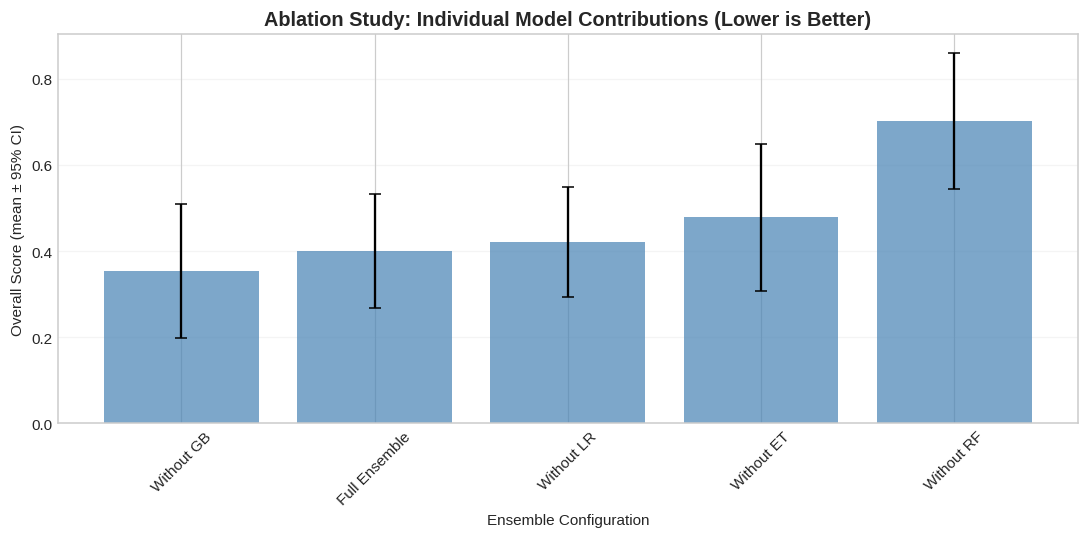

✓ Model ablation complete


In [12]:
BEST_TUNED_CFG = {
    "hard_wait_guard": 0.6684,
    "soft_wait_guard": 0.4512,
    "green_weight": 0.0236,
    "soft_penalty_carbon": 0.0667,
    "soft_penalty_carbon_guarded": 0.0214,
    "bonus_scale": 0.9441,
    "model_weights": {"rf": 0.5891, "et": 0.2066, "gb": 0.1751, "lr": 0.0291},
}

ablation_cfg = {
    "seeds": list(range(6)),
    "noises": [20.0],
    "congestions": ["high"],
    "capacities": [6],
}

print("Running model component ablation...")
ablation_rows = []
ablation_models = [
    ("Full Ensemble", []),
    ("Without RF", ["rf"]),
    ("Without ET", ["et"]),
    ("Without GB", ["gb"]),
    ("Without LR", ["lr"]),
]
for model_name, excluded in tqdm(ablation_models, desc="Ablation", unit="config"):
    for seed in ablation_cfg["seeds"]:
        for noise in ablation_cfg["noises"]:
            for cong in ablation_cfg["congestions"]:
                for cap in ablation_cfg["capacities"]:
                    result = run_policy_episode(
                        v2_eval, seed, noise, cong, cap, "ml_ensemble_green",
                        bundle=bundle_v2,
                        ensemble_cfg=BEST_TUNED_CFG,
                        excluded_models=excluded,
                    )
                    result["ablation_config"] = model_name
                    ablation_rows.append(result)

ablation_df = pd.DataFrame(ablation_rows)
ablation_df["dataset_track"] = "v2_realworld"
ablation_scored = compute_overall_score_robust(ablation_df, OVERALL_WEIGHTS)

ablation_summary = ablation_scored.groupby("ablation_config", as_index=False).agg(
    n=("seed", "count"),
    overall_score_mean=("overall_score", "mean"),
    overall_score_std=("overall_score", "std"),
    carbon_per_completed_job_mean=("carbon_per_completed_job", "mean"),
    avg_jct_mean=("avg_jct_h", "mean"),
    tail_jct_mean=("tail_jct_h", "mean"),
)
ablation_summary["overall_score_ci"] = 1.96 * ablation_summary["overall_score_std"] / np.sqrt(ablation_summary["n"].clip(lower=1))

full_scores = ablation_scored[ablation_scored["ablation_config"] == "Full Ensemble"]["seed"].to_frame()
full_scores["full_score"] = ablation_scored[ablation_scored["ablation_config"] == "Full Ensemble"]["overall_score"].values

comp_rows = []
for config in ablation_summary["ablation_config"]:
    if config == "Full Ensemble":
        continue
    other = ablation_scored[ablation_scored["ablation_config"] == config][["seed", "overall_score"]]
    merged = full_scores.merge(other, on="seed", how="inner")
    if len(merged) == 0:
        continue
    diff = merged["overall_score"] - merged["full_score"]
    mean_diff, ci_lo, ci_hi, p_val = bootstrap_mean_ci(diff)
    comp_rows.append({
        "ablation_config": config,
        "diff_vs_full_mean": mean_diff,
        "diff_vs_full_ci_low": ci_lo,
        "diff_vs_full_ci_high": ci_hi,
        "diff_vs_full_p": p_val,
    })

comp_df = pd.DataFrame(comp_rows)
if not comp_df.empty:
    ablation_summary = ablation_summary.merge(comp_df, on="ablation_config", how="left")

print("\n=== Model Ablation Results ===")
print("Note: Positive diff_vs_full_mean means worse than Full Ensemble (lower is better).")
display(ablation_summary.round(5))

fig, ax = plt.subplots(figsize=(10, 5))
ablation_summary_sorted = ablation_summary.sort_values("overall_score_mean")
ax.bar(
    ablation_summary_sorted["ablation_config"],
    ablation_summary_sorted["overall_score_mean"],
    yerr=ablation_summary_sorted["overall_score_ci"],
    capsize=4,
    alpha=0.7,
    color="steelblue",
)
ax.set_title("Ablation Study: Individual Model Contributions (Lower is Better)", fontsize=13, fontweight="bold")
ax.set_ylabel("Overall Score (mean ± 95% CI)")
ax.set_xlabel("Ensemble Configuration")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

print("✓ Model ablation complete")

## 11. Run Guard Threshold Ablations

Sweep guard thresholds and compare against the baseline configuration.

Running guard threshold ablation...


Guard Ablation: 100%|██████████| 5/5 [05:45<00:00, 69.18s/config]



=== Guard Threshold Ablation Results ===
Note: Positive diff_vs_baseline_mean means worse than baseline (lower is better).


,guard_config,n,overall_score_mean,carbon_per_completed_job_mean,avg_jct_mean,tail_jct_mean,diff_vs_baseline_mean,diff_vs_baseline_ci_low,diff_vs_baseline_ci_high,diff_vs_baseline_p
0,Aggressive (0.60/0.40),6,0.45154,0.34507,1.27608,5.45139,0.01638,-0.03169,0.09039,0.697
1,Baseline (0.668/0.451),6,0.43516,0.34601,1.29016,5.51042,NaN,NaN,NaN,NaN
2,Conservative (0.75/0.55),6,0.51336,0.34600,1.29590,5.52847,0.07820,-0.06843,0.20328,0.313
3,Very Aggressive (0.55/0.35),6,0.41534,0.34493,1.27710,5.45694,-0.01982,-0.16105,0.11655,0.789
4,Very Conservative (0.85/0.65),6,0.53950,0.34521,1.31702,5.77222,0.10434,0.04184,0.19043,0.000


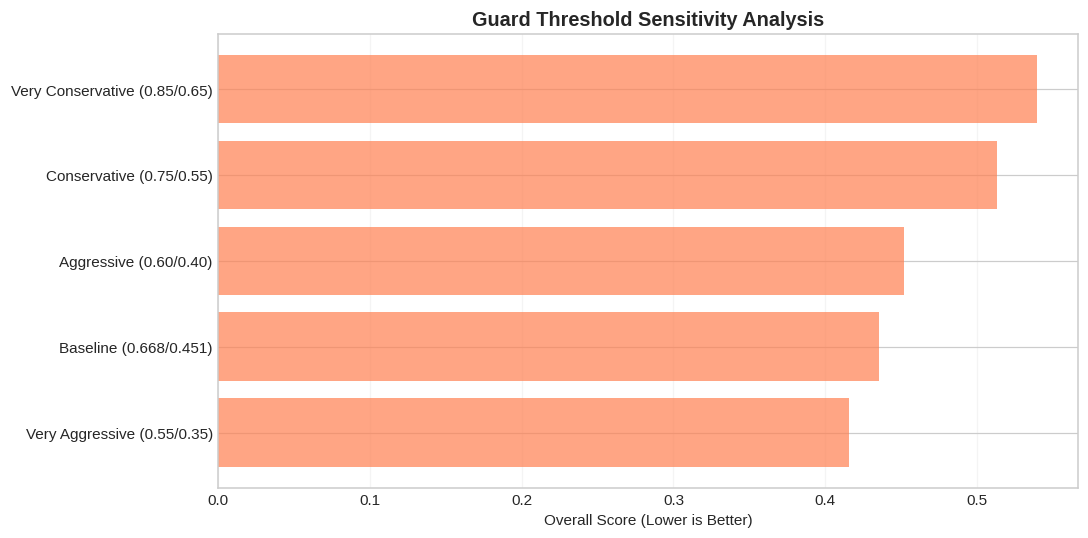

✓ Guard ablation complete


In [13]:
print("Running guard threshold ablation...")
guard_variations = [
    ("Baseline (0.668/0.451)", {"hard_wait_guard": 0.668, "soft_wait_guard": 0.451}),
    ("Aggressive (0.60/0.40)", {"hard_wait_guard": 0.60, "soft_wait_guard": 0.40}),
    ("Conservative (0.75/0.55)", {"hard_wait_guard": 0.75, "soft_wait_guard": 0.55}),
    ("Very Aggressive (0.55/0.35)", {"hard_wait_guard": 0.55, "soft_wait_guard": 0.35}),
    ("Very Conservative (0.85/0.65)", {"hard_wait_guard": 0.85, "soft_wait_guard": 0.65}),
]

guard_rows = []
for guard_name, guard_cfg in tqdm(guard_variations, desc="Guard Ablation", unit="config"):
    for seed in ablation_cfg["seeds"]:
        test_cfg = dict(BEST_TUNED_CFG)
        test_cfg.update(guard_cfg)
        result = run_policy_episode(
            v2_eval, seed, 20.0, "high", 6, "ml_ensemble_green",
            bundle=bundle_v2,
            ensemble_cfg=test_cfg,
        )
        result["guard_config"] = guard_name
        guard_rows.append(result)

guard_df = pd.DataFrame(guard_rows)
guard_df["dataset_track"] = "v2_realworld"
guard_scored = compute_overall_score_robust(guard_df, OVERALL_WEIGHTS)

guard_summary = guard_scored.groupby("guard_config", as_index=False).agg(
    n=("seed", "count"),
    overall_score_mean=("overall_score", "mean"),
    carbon_per_completed_job_mean=("carbon_per_completed_job", "mean"),
    avg_jct_mean=("avg_jct_h", "mean"),
    tail_jct_mean=("tail_jct_h", "mean"),
)

baseline_name = "Baseline (0.668/0.451)"
baseline_scores = guard_scored[guard_scored["guard_config"] == baseline_name][["seed", "overall_score"]].rename(columns={"overall_score": "baseline_score"})

guard_comp_rows = []
for config in guard_summary["guard_config"]:
    if config == baseline_name:
        continue
    other = guard_scored[guard_scored["guard_config"] == config][["seed", "overall_score"]]
    merged = baseline_scores.merge(other, on="seed", how="inner")
    if len(merged) == 0:
        continue
    diff = merged["overall_score"] - merged["baseline_score"]
    mean_diff, ci_lo, ci_hi, p_val = bootstrap_mean_ci(diff)
    guard_comp_rows.append({
        "guard_config": config,
        "diff_vs_baseline_mean": mean_diff,
        "diff_vs_baseline_ci_low": ci_lo,
        "diff_vs_baseline_ci_high": ci_hi,
        "diff_vs_baseline_p": p_val,
    })

guard_comp_df = pd.DataFrame(guard_comp_rows)
if not guard_comp_df.empty:
    guard_summary = guard_summary.merge(guard_comp_df, on="guard_config", how="left")

print("\n=== Guard Threshold Ablation Results ===")
print("Note: Positive diff_vs_baseline_mean means worse than baseline (lower is better).")
display(guard_summary.round(5))

fig, ax = plt.subplots(figsize=(10, 5))
guard_summary_sorted = guard_summary.sort_values("overall_score_mean")
ax.barh(guard_summary_sorted["guard_config"], guard_summary_sorted["overall_score_mean"], alpha=0.7, color="coral")
ax.set_title("Guard Threshold Sensitivity Analysis", fontsize=13, fontweight="bold")
ax.set_xlabel("Overall Score (Lower is Better)")
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

print("✓ Guard ablation complete")

## 12. Run Generalization Validation Sweep

Evaluate across noise, congestion, and capacity combinations and compare SRTF vs ensemble.

Running generalization validation across all noise/capacity combinations...


Generalization: 100%|██████████| 32/32 [06:14<00:00, 11.70s/combo]


=== Generalization Test Results (All Configurations) ===


,noise_pct,congestion,capacity,policy,n,overall_score_mean,overall_score_std,carbon_per_completed_job_mean,avg_jct_mean,tail_jct_mean
0,10.0,high,6,ml_ensemble_green,4,0.5750,0.24664,0.34082,1.38222,6.13125
1,10.0,high,6,srtf,4,0.4250,0.24664,0.34266,1.25193,5.55729
2,10.0,high,8,ml_ensemble_green,4,0.6000,0.24833,0.42054,1.22616,5.42396
3,10.0,high,8,srtf,4,0.4000,0.24833,0.42345,1.13787,5.10417
4,10.0,moderate,6,ml_ensemble_green,4,0.6625,0.29262,0.47487,1.18496,4.98854
5,10.0,moderate,6,srtf,4,0.3375,0.29262,0.47679,1.09908,4.77708
6,10.0,moderate,8,ml_ensemble_green,4,0.5750,0.05000,0.57524,1.14311,4.99271
7,10.0,moderate,8,srtf,4,0.4250,0.05000,0.57570,1.09992,4.77187
8,20.0,high,6,ml_ensemble_green,4,0.5500,0.28577,0.34035,1.39659,6.15312
9,20.0,high,6,srtf,4,0.4500,0.28577,0.34160,1.25193,5.55729


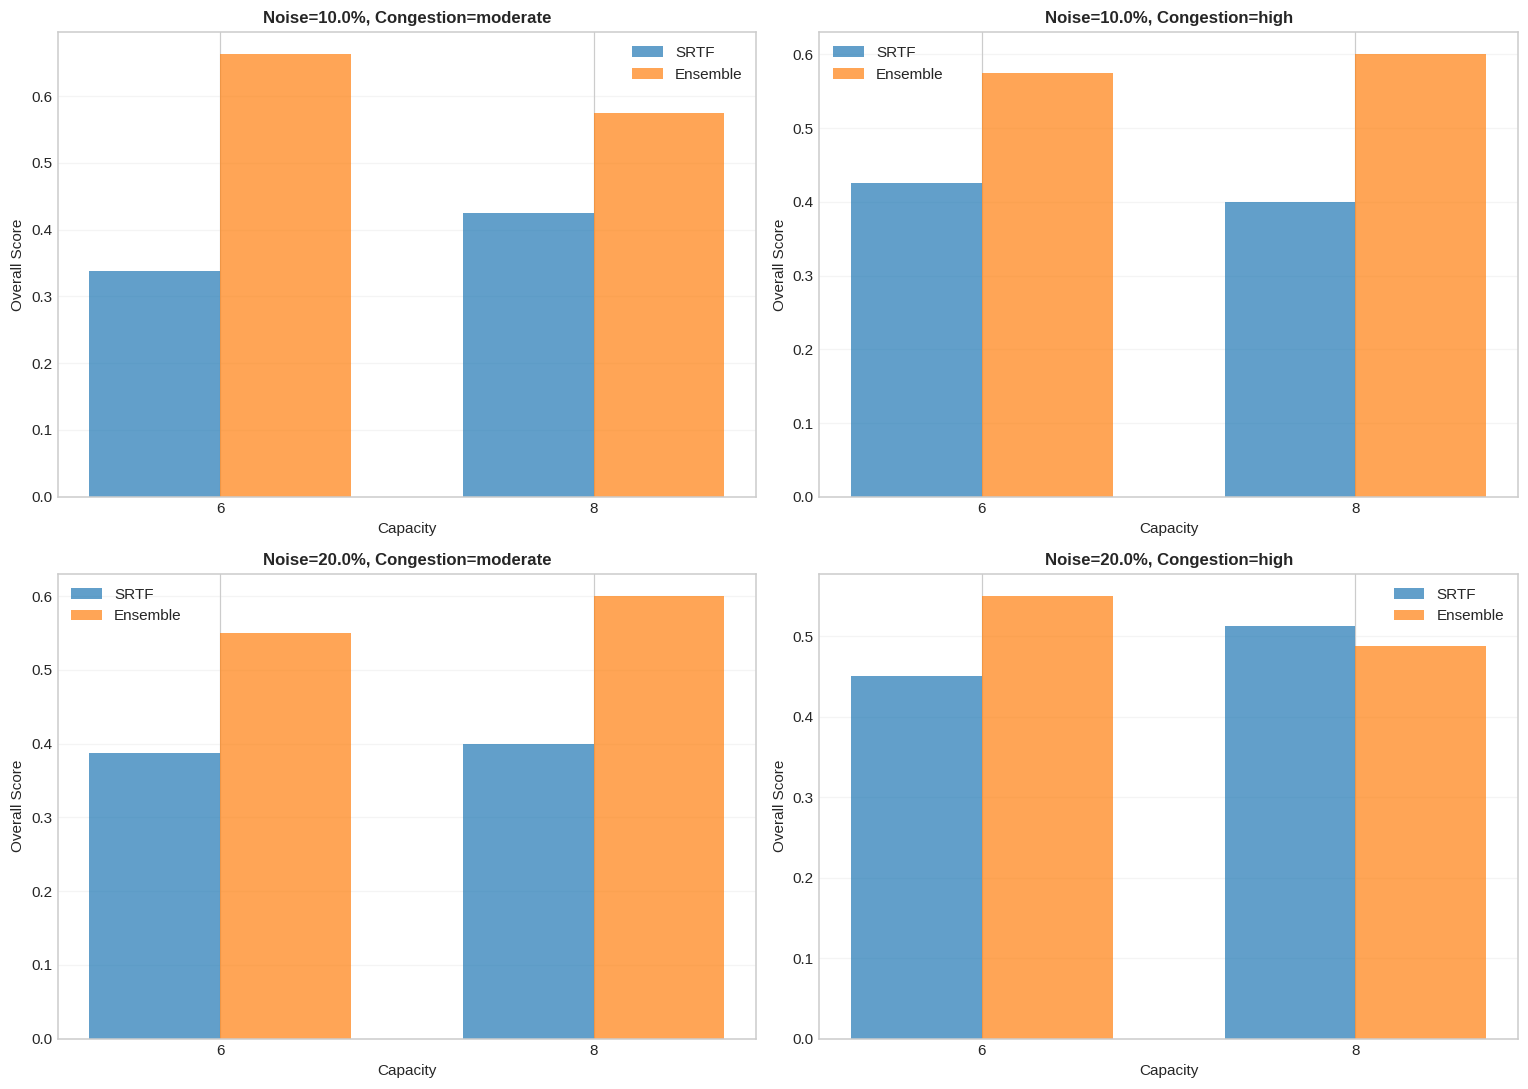

✓ Generalization validation complete


In [14]:
print("Running generalization validation across all noise/capacity combinations...")
gen_cfg = {
    "seeds": list(range(4)),
    "noises": [10.0, 20.0],
    "congestions": ["moderate", "high"],
    "capacities": [6, 8],
}

gen_rows = []
combos = [(s, n, c, k) for s in gen_cfg["seeds"] for n in gen_cfg["noises"] for c in gen_cfg["congestions"] for k in gen_cfg["capacities"]]
for seed, noise, congestion, capacity in tqdm(combos, desc="Generalization", unit="combo"):
    for policy in ["srtf", "ml_ensemble_green"]:
        result = run_policy_episode(
            v2_eval, seed, noise, congestion, capacity, policy,
            bundle=bundle_v2 if policy == "ml_ensemble_green" else None,
            ensemble_cfg=BEST_TUNED_CFG if policy == "ml_ensemble_green" else None,
        )
        gen_rows.append(result)

gen_df = pd.DataFrame(gen_rows)
gen_df["dataset_track"] = "v2_realworld"
gen_scored = compute_overall_score_robust(gen_df, OVERALL_WEIGHTS)

gen_summary = gen_scored.groupby(["noise_pct", "congestion", "capacity", "policy"], as_index=False).agg(
    n=("seed", "count"),
    overall_score_mean=("overall_score", "mean"),
    overall_score_std=("overall_score", "std"),
    carbon_per_completed_job_mean=("carbon_per_completed_job", "mean"),
    avg_jct_mean=("avg_jct_h", "mean"),
    tail_jct_mean=("tail_jct_h", "mean"),
).round(5)

print("\n=== Generalization Test Results (All Configurations) ===")
display(gen_summary)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, noise in enumerate([10.0, 20.0]):
    for j, congestion in enumerate(["moderate", "high"]):
        ax = axes[i, j]
        subset = gen_summary[(gen_summary["noise_pct"] == noise) & (gen_summary["congestion"] == congestion)]
        srtf_data = subset[subset["policy"] == "srtf"].sort_values("capacity")
        ensemble_data = subset[subset["policy"] == "ml_ensemble_green"].sort_values("capacity")
        if len(srtf_data) > 0 and len(ensemble_data) > 0:
            capacities = sorted(set(srtf_data["capacity"].values) & set(ensemble_data["capacity"].values))
            x = np.arange(len(capacities))
            width = 0.35
            srtf_vals = [
                srtf_data[srtf_data["capacity"] == c]["overall_score_mean"].values[0]
                if len(srtf_data[srtf_data["capacity"] == c]) > 0
                else 0
                for c in capacities
            ]
            ensemble_vals = [
                ensemble_data[ensemble_data["capacity"] == c]["overall_score_mean"].values[0]
                if len(ensemble_data[ensemble_data["capacity"] == c]) > 0
                else 0
                for c in capacities
            ]
            ax.bar(x - width / 2, srtf_vals, width, label="SRTF", alpha=0.7)
            ax.bar(x + width / 2, ensemble_vals, width, label="Ensemble", alpha=0.7)
            ax.set_title(f"Noise={noise}%, Congestion={congestion}", fontsize=11, fontweight="bold")
            ax.set_ylabel("Overall Score")
            ax.set_xlabel("Capacity")
            ax.set_xticks(x)
            ax.set_xticklabels(capacities)
            ax.legend()
            ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

print("✓ Generalization validation complete")

## 12A. Optimal Ensemble Use (Weights and Pruning)

Search a small candidate set of weightings and pruned variants to find a more consistent ensemble configuration. This updates `ACTIVE_CFG` for later sections.

In [15]:
if "BEST_TUNED_CFG" not in globals():
    BEST_TUNED_CFG = {
        "hard_wait_guard": 0.6684,
        "soft_wait_guard": 0.4512,
        "green_weight": 0.0236,
        "soft_penalty_carbon": 0.0667,
        "soft_penalty_carbon_guarded": 0.0214,
        "bonus_scale": 0.9441,
        "model_weights": {"rf": 0.5891, "et": 0.2066, "gb": 0.1751, "lr": 0.0291},
    }

if "gen_cfg" not in globals():
    gen_cfg = {
        "seeds": list(range(4)),
        "noises": [10.0, 20.0],
        "congestions": ["moderate", "high"],
        "capacities": [6, 8],
    }

if "normalize_model_weights" not in globals():
    def normalize_model_weights(raw: dict[str, float]) -> dict[str, float]:
        total = max(1e-8, float(sum(raw.values())))
        return {k: float(v) / total for k, v in raw.items()}

ACTIVE_CFG = dict(BEST_TUNED_CFG)
ACTIVE_EXCLUDED = []

def _make_cfg_with_weights(weights: dict[str, float]) -> dict:
    cfg = dict(BEST_TUNED_CFG)
    cfg["model_weights"] = normalize_model_weights(weights)
    return cfg

def _zero_model(weights: dict[str, float], model_name: str) -> dict[str, float]:
    out = dict(weights)
    out[model_name] = 0.0
    return out

def _eval_cfg(cfg: dict, excluded_models: list[str], label: str, combos: list[tuple]) -> dict:
    rows = []
    # Added tqdm progress bar here!
    from tqdm import tqdm
    for seed, noise, congestion, capacity in tqdm(combos, desc=f"Evaluating {label}", leave=False):
        result = run_policy_episode(
            v2_eval, seed, noise, congestion, capacity, "ml_ensemble_green",
            bundle=bundle_v2,
            ensemble_cfg=cfg,
            excluded_models=excluded_models,
        )
        rows.append(result)
    df = pd.DataFrame(rows)
    df["dataset_track"] = "v2_realworld"
    scored = compute_overall_score_robust(df, OVERALL_WEIGHTS)
    return {
        "label": label,
        "excluded": ",".join(excluded_models) if excluded_models else "none",
        "overall_score_mean": float(scored["overall_score"].mean()),
        "overall_score_std": float(scored["overall_score"].std()),
        "carbon_per_completed_job_mean": float(scored["carbon_per_completed_job"].mean()),
        "avg_jct_mean": float(scored["avg_jct_h"].mean()),
        "tail_jct_mean": float(scored["tail_jct_h"].mean()),
        "cfg": cfg,
    }

print("Running optimal-weight search (Balanced Candidate Set)...")
# BALANCED: Only use 2 seeds instead of 4 to cut time in half, but keep all variations.
tuning_combos = [(s, n, c, k) for s in [0, 1] for n in gen_cfg["noises"] for c in gen_cfg["congestions"] for k in gen_cfg["capacities"]]

base_weights = dict(BEST_TUNED_CFG["model_weights"])
candidates = []
candidates.append(("base", _make_cfg_with_weights(base_weights), []))
candidates.append(("no_gb", _make_cfg_with_weights(_zero_model(base_weights, "gb")), ["gb"]))
candidates.append(("no_et", _make_cfg_with_weights(_zero_model(base_weights, "et")), ["et"]))
candidates.append(("no_lr", _make_cfg_with_weights(_zero_model(base_weights, "lr")), ["lr"]))
candidates.append(("no_rf", _make_cfg_with_weights(_zero_model(base_weights, "rf")), ["rf"]))
candidates.append(("rf_heavy", _make_cfg_with_weights({"rf": 0.70, "et": 0.15, "gb": 0.10, "lr": 0.05}), []))
candidates.append(("et_heavy", _make_cfg_with_weights({"rf": 0.20, "et": 0.60, "gb": 0.15, "lr": 0.05}), []))
candidates.append(("gb_light", _make_cfg_with_weights({"rf": 0.55, "et": 0.25, "gb": 0.10, "lr": 0.10}), []))

rng = np.random.default_rng(SEED)
for i in range(8):
    raw = rng.dirichlet(np.ones(4))
    rand_weights = {"rf": raw[0], "et": raw[1], "gb": raw[2], "lr": raw[3]}
    candidates.append((f"rand_{i+1}", _make_cfg_with_weights(rand_weights), []))

# Wrap candidates in tqdm for outer completion tracking
from tqdm import tqdm
tuning_rows = []
for label, cfg, excluded in tqdm(candidates, desc="Overall Config Progress"):
    tuning_rows.append(_eval_cfg(cfg, excluded, label, tuning_combos))

tuning_summary = pd.DataFrame(tuning_rows).sort_values("overall_score_mean")
display(tuning_summary[["label", "excluded", "overall_score_mean", "overall_score_std", "carbon_per_completed_job_mean", "avg_jct_mean", "tail_jct_mean"]].round(5))

best_row = tuning_summary.iloc[0]
ACTIVE_CFG = best_row["cfg"]
ACTIVE_EXCLUDED = [] if best_row["excluded"] == "none" else best_row["excluded"].split(",")
print(f"✓ Best config: {best_row['label']} | excluded={best_row['excluded']} | score={best_row['overall_score_mean']:.4f}")

Running optimal-weight search (Balanced Candidate Set)...


Overall Config Progress: 100%|██████████| 16/16 [46:26<00:00, 174.17s/it]


,label,excluded,overall_score_mean,overall_score_std,carbon_per_completed_job_mean,avg_jct_mean,tail_jct_mean
0,base,none,0.0,0.0,0.43561,1.26216,5.43542
1,no_gb,gb,0.0,0.0,0.43694,1.23118,5.40833
2,no_et,et,0.0,0.0,0.43458,1.29051,5.43516
3,no_lr,lr,0.0,0.0,0.43609,1.25455,5.42604
4,no_rf,rf,0.0,0.0,0.43452,1.34835,5.56458
5,rf_heavy,none,0.0,0.0,0.43585,1.25728,5.39323
6,et_heavy,none,0.0,0.0,0.43635,1.24160,5.37187
7,gb_light,none,0.0,0.0,0.43572,1.26107,5.44297
8,rand_1,none,0.0,0.0,0.43460,1.29710,5.49948
9,rand_2,none,0.0,0.0,0.42648,1.67079,6.47318


✓ Best config: base | excluded=none | score=0.0000


## 13. Run Failure Mode Analysis

Compute performance gaps, summarize worst/best cases, and visualize distributions.

Analyzing failure modes...


Failure Analysis: 100%|██████████| 32/32 [06:18<00:00, 11.82s/combo]


=== Failure Mode Metrics ===
Worst ensemble performance (gap): 0.8000
Best ensemble performance (gap): -0.8000
Mean performance gap: 0.1578
Std performance gap: 0.4524

Failure ratio (ensemble worse than SRTF): 75.00%

=== Top 5 Worst Cases for Ensemble ===


,seed,noise_pct,congestion,capacity,performance_gap,srtf_score,ensemble_score
2,0,10.0,high,6,0.8,0.1,0.9
6,0,20.0,high,6,0.8,0.1,0.9
8,1,10.0,moderate,6,0.8,0.1,0.9
11,1,10.0,high,8,0.8,0.1,0.9
15,1,20.0,high,8,0.8,0.1,0.9



=== Top 5 Best Cases for Ensemble (Where it wins) ===


,seed,noise_pct,congestion,capacity,performance_gap,srtf_score,ensemble_score
31,3,20.0,high,8,-0.8,0.9,0.1
30,3,20.0,high,6,-0.6,0.8,0.2
7,0,20.0,high,8,-0.4,0.7,0.3
13,1,20.0,moderate,8,-0.4,0.7,0.3
24,3,10.0,moderate,6,-0.4,0.7,0.3


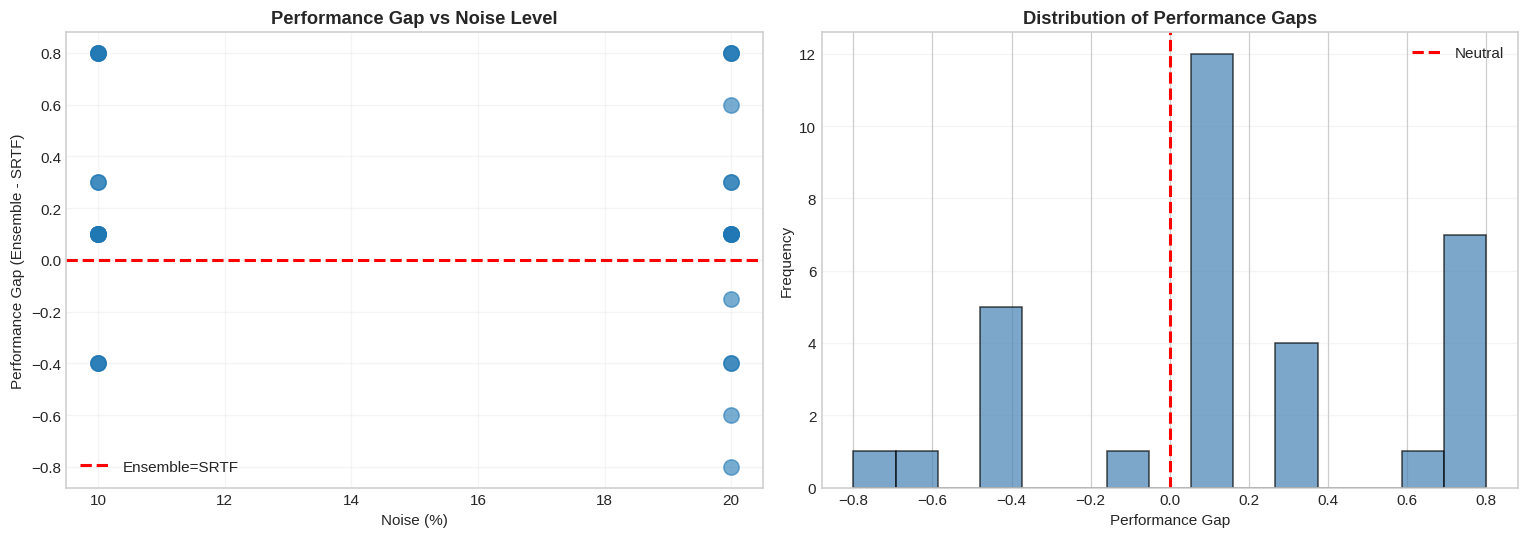

✓ Failure mode analysis complete


In [16]:
print("Analyzing failure modes...")
failure_rows = []
for seed, noise, congestion, capacity in tqdm(combos, desc="Failure Analysis", unit="combo"):
    srtf_result = run_policy_episode(v2_eval, seed, noise, congestion, capacity, "srtf", bundle=bundle_v2)
    ensemble_result = run_policy_episode(
        v2_eval, seed, noise, congestion, capacity, "ml_ensemble_green",
        bundle=bundle_v2, ensemble_cfg=ACTIVE_CFG, excluded_models=ACTIVE_EXCLUDED,
    )
    pair_df = pd.DataFrame([srtf_result, ensemble_result])
    pair_df["dataset_track"] = "v2_realworld"
    pair_scored = compute_overall_score_robust(pair_df, OVERALL_WEIGHTS)
    srtf_row = pair_scored[pair_scored["policy"] == "srtf"].iloc[0]
    ensemble_row = pair_scored[pair_scored["policy"] == "ml_ensemble_green"].iloc[0]
    srtf_score = float(srtf_row["overall_score"])
    ensemble_score = float(ensemble_row["overall_score"])
    gap = ensemble_score - srtf_score
    failure_rows.append({
        "seed": seed,
        "noise_pct": noise,
        "congestion": congestion,
        "capacity": capacity,
        "srtf_score": srtf_score,
        "ensemble_score": ensemble_score,
        "performance_gap": gap,
        "srtf_carbon_per_job": float(srtf_row["carbon_per_completed_job"]),
        "ensemble_carbon_per_job": float(ensemble_row["carbon_per_completed_job"]),
        "srtf_avg_jct": float(srtf_row["avg_jct_h"]),
        "ensemble_avg_jct": float(ensemble_row["avg_jct_h"]),
    })

failure_df = pd.DataFrame(failure_rows)

print("\n=== Failure Mode Metrics ===")
print(f"Worst ensemble performance (gap): {failure_df['performance_gap'].max():.4f}")
print(f"Best ensemble performance (gap): {failure_df['performance_gap'].min():.4f}")
print(f"Mean performance gap: {failure_df['performance_gap'].mean():.4f}")
print(f"Std performance gap: {failure_df['performance_gap'].std():.4f}")
print(f"\nFailure ratio (ensemble worse than SRTF): {(failure_df['performance_gap'] > 0).mean():.2%}")

worst_cases = failure_df.nlargest(5, "performance_gap")[["seed", "noise_pct", "congestion", "capacity", "performance_gap", "srtf_score", "ensemble_score"]]
print("\n=== Top 5 Worst Cases for Ensemble ===")
display(worst_cases.round(5))

best_cases = failure_df.nsmallest(5, "performance_gap")[["seed", "noise_pct", "congestion", "capacity", "performance_gap", "srtf_score", "ensemble_score"]]
print("\n=== Top 5 Best Cases for Ensemble (Where it wins) ===")
display(best_cases.round(5))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(failure_df["noise_pct"], failure_df["performance_gap"], alpha=0.6, s=100)
axes[0].axhline(y=0, color="r", linestyle="--", linewidth=2, label="Ensemble=SRTF")
axes[0].set_xlabel("Noise (%)")
axes[0].set_ylabel("Performance Gap (Ensemble - SRTF)")
axes[0].set_title("Performance Gap vs Noise Level", fontweight="bold")
axes[0].grid(alpha=0.2)
axes[0].legend()

axes[1].hist(failure_df["performance_gap"], bins=15, alpha=0.7, color="steelblue", edgecolor="black")
axes[1].axvline(x=0, color="r", linestyle="--", linewidth=2, label="Neutral")
axes[1].set_xlabel("Performance Gap")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of Performance Gaps", fontweight="bold")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

print("✓ Failure mode analysis complete")

## 14. Benchmark Computational Overhead

Measure inference latency vs a heuristic baseline and visualize distributions.

Measuring computational overhead...
Benchmarking Ensemble Inference (5000 iterations)...
Benchmarking Heuristic Dispatch (50000 iterations)...

=== Computational Overhead Analysis ===
Overhead Ratio: 3595.6x


,component,mean_latency_ms,std_latency_ms,p50_latency_ms,p95_latency_ms,p99_latency_ms
0,Ensemble Inference,40.0667,9.2412,35.4533,59.278,66.6149
1,Heuristic Dispatch,0.0111,0.0072,0.0086,0.020,0.0277


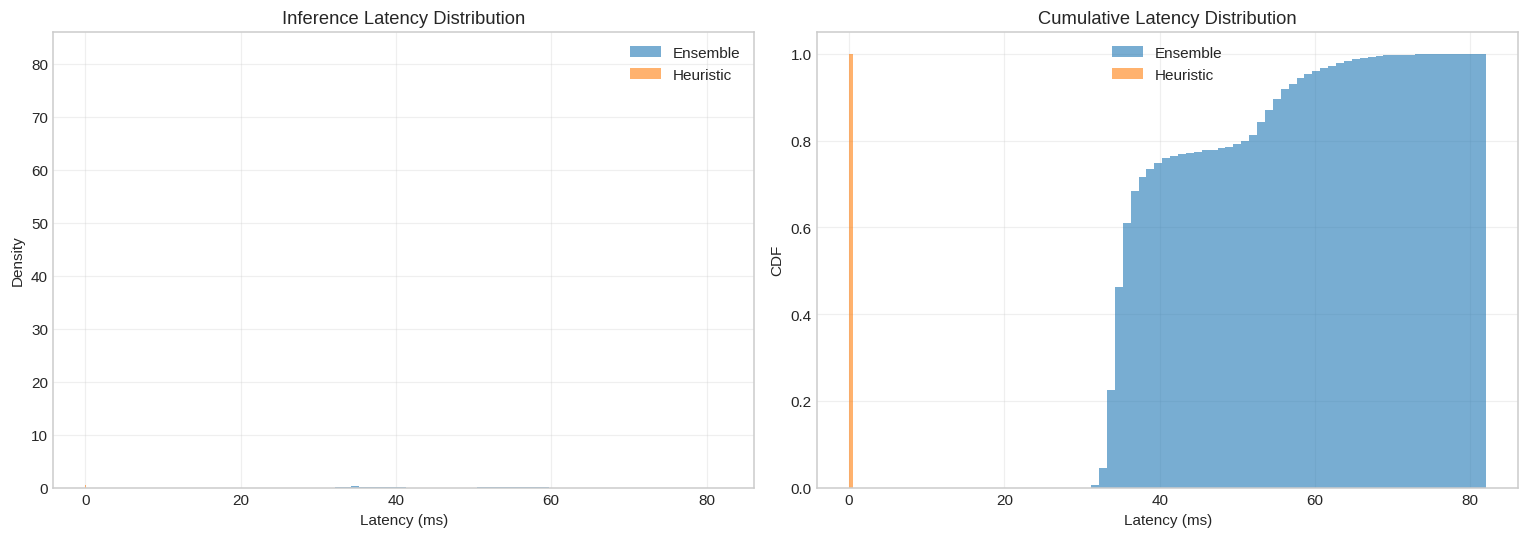

✓ Computational overhead analysis complete


In [17]:
print("Measuring computational overhead...")

def benchmark_inference_latency(bundle, cfg, n_iterations=5000):
    times = []
    dummy_state = np.array([0.5, 0.4, 0.6, 0.3, 0.7, 0.2, 0.1, 0.45, 0.25])
    dummy_feat = np.asarray([dummy_state], dtype=np.float32)
    for _ in range(n_iterations):
        start = time.time()
        scores = predict_action_scores(bundle["models"], cfg.get("model_weights", bundle["weights"]), dummy_feat)
        _ = choose_action_ensemble_green(
            scores,
            dummy_state,
            hard_wait_guard=float(cfg.get("hard_wait_guard", 0.72)),
            soft_wait_guard=float(cfg.get("soft_wait_guard", 0.56)),
            green_weight=float(cfg.get("green_weight", 0.16)),
            green_bonus=cfg.get("green_bonus", {a: 0.0 for a in CANDIDATE_ACTIONS}),
            soft_penalty_carbon=float(cfg.get("soft_penalty_carbon", 0.08)),
            soft_penalty_carbon_guarded=float(cfg.get("soft_penalty_carbon_guarded", 0.04)),
        )
        elapsed = time.time() - start
        times.append(elapsed * 1000)
    return np.array(times)

def benchmark_heuristic_latency(n_iterations=50000):
    times = []
    for _ in range(n_iterations):
        start = time.time()
        _ = np.random.choice([1, 2, 3, 4])
        elapsed = time.time() - start
        times.append(elapsed * 1000)
    return np.array(times)

print("Benchmarking Ensemble Inference (5000 iterations)...")
ensemble_times = benchmark_inference_latency(bundle_v2, ACTIVE_CFG, n_iterations=5000)
print("Benchmarking Heuristic Dispatch (50000 iterations)...")
heuristic_times = benchmark_heuristic_latency(n_iterations=50000)

overhead_ratio = ensemble_times.mean() / heuristic_times.mean()
overhead_summary = pd.DataFrame({
    "component": ["Ensemble Inference", "Heuristic Dispatch"],
    "mean_latency_ms": [ensemble_times.mean(), heuristic_times.mean()],
    "std_latency_ms": [ensemble_times.std(), heuristic_times.std()],
    "p50_latency_ms": [np.percentile(ensemble_times, 50), np.percentile(heuristic_times, 50)],
    "p95_latency_ms": [np.percentile(ensemble_times, 95), np.percentile(heuristic_times, 95)],
    "p99_latency_ms": [np.percentile(ensemble_times, 99), np.percentile(heuristic_times, 99)],
})

print("\n=== Computational Overhead Analysis ===")
print(f"Overhead Ratio: {overhead_ratio:.1f}x")
display(overhead_summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(ensemble_times, bins=50, alpha=0.6, label="Ensemble", density=True)
axes[0].hist(heuristic_times, bins=50, alpha=0.6, label="Heuristic", density=True)
axes[0].set_xlabel("Latency (ms)")
axes[0].set_ylabel("Density")
axes[0].set_title("Inference Latency Distribution")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(ensemble_times, bins=50, alpha=0.6, label="Ensemble", cumulative=True, density=True)
axes[1].hist(heuristic_times, bins=50, alpha=0.6, label="Heuristic", cumulative=True, density=True)
axes[1].set_xlabel("Latency (ms)")
axes[1].set_ylabel("CDF")
axes[1].set_title("Cumulative Latency Distribution")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Computational overhead analysis complete")

## 15. Export Result Tables

Save ablation, generalization, failure, and overhead results for reporting.

In [19]:
import os
import json
from pathlib import Path

in_colab = "COLAB_RELEASE_TAG" in os.environ or "COLAB_GPU" in os.environ
default_local = Path("../data")
default_colab = Path("/content/eco_cloud_outputs")
drive_dir = Path("/content/drive/MyDrive/eco_cloud_outputs")

export_dir = Path(os.environ.get("ECO_CLOUD_EXPORT_DIR", ""))
if not export_dir.as_posix().strip():
    if in_colab and drive_dir.exists():
        export_dir = drive_dir
    elif in_colab:
        export_dir = default_colab
    else:
        export_dir = default_local

export_dir.mkdir(parents=True, exist_ok=True)
print(f"Export directory: {export_dir}")

ablation_summary.to_csv(export_dir / "optimal_ablation_results.csv", index=False)
gen_summary.to_csv(export_dir / "optimal_generalization_results.csv", index=False)
failure_df.to_csv(export_dir / "optimal_failure_modes.csv", index=False)
overhead_summary.to_csv(export_dir / "optimal_overhead_analysis.csv", index=False)
tuning_summary.to_csv(export_dir / "optimal_tuning_summary.csv", index=False)

with open(export_dir / "optimal_best_cfg.json", "w") as f:
    json.dump(ACTIVE_CFG, f, indent=4)
print("✓ Saved optimal_best_cfg.json")

Export directory: .
✓ Saved optimal_best_cfg.json
